# Section 1: Introduction:
In today's competitive business landscape, retaining customers is more crucial than ever. Companies often invest heavily in acquiring new customers, yet the cost of losing an existing customer can be even greater.

Understanding the factors that lead to customer churn—when a customer decides to stop using a service—is essential for creating effective retention strategies. Imagine having the power to predict which customers are at risk of leaving, enabling you to proactively address their needs and concerns before they decide to go.

<center><img src="https://www.cleartouch.in/wp-content/uploads/2022/11/Customer-Churn.png" width=500/></center>

By analyzing a comprehensive dataset that includes customer demographics, account details, and the services they've subscribed to, you can uncover the underlying reasons for churn. This knowledge allows businesses to tailor their retention programs, offering personalized solutions that enhance customer satisfaction and loyalty, ultimately driving long-term growth and profitability. Let's harness the power of data to not only understand why customers leave but to keep them engaged and committed to your brand.

# Section 2: Import the necessary Libraries

In [24]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE

# Section 3: Loading the Data

Download the data [here](https://www.kaggle.com/datasets/blastchar/telco-customer-churn).

**Dataset Information:**

**Content:**
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

The data set includes information about:

- Customers who left within the last month – the column is called `Churn`.
- ervices that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies.
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
Demographic info about customers – gender, age range, and if they have partners and dependents.

In [25]:
# Mounting the drive

from google.colab import drive
drive.mount('/content/drive')

# Load the data

# 1. Define your localized Git structure path
data_path = "data/Telco-Customer-Churn.csv"

# 2. Smart fallback if running on Google Colab
if not os.path.exists(data_path):
    from google.colab import drive
    drive.mount('/content/drive',force_remount=True)
    data_path = "/content/drive/MyDrive/Colab Notebooks/Telco-Customer-Churn.csv"

# 3. Load the data using the resolved path
df = pd.read_csv(data_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mounted at /content/drive


In [26]:

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [27]:
# Remove the column - 'customerID'
df=df.drop(columns=['customerID'],axis=1)

In [28]:
# Checking the data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


# Section 4: EDA
EDA is the process of analyzing and visualizing the dataset to uncover underlying patterns, trends, and relationships. It helps in understanding the data's structure and guiding the feature selection and modeling process.

## 4.1 Check the distribution of the target variable - `Churn`.


<Axes: xlabel='Churn', ylabel='count'>

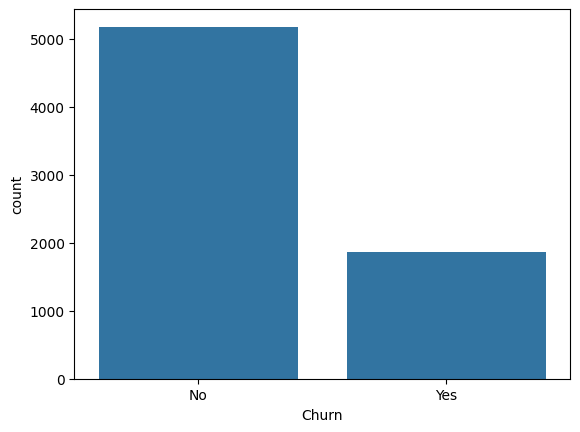

In [29]:
# Check the distribution of the target variable
sns.countplot(data=df,x='Churn')

In [30]:
#sns.histplot(data=df['gender'].value_counts().to_list())
df['gender'].value_counts().to_list()


[3555, 3488]

## 4.2 Do an analysis of the churn rate wrt all the categorical variables

*Hint: Use normalized values to plot to avoid the class imbalance problem.*

In [31]:
# Analyze churn rate by categorical features
# Listing all the categorical columns
categorical_columns = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]


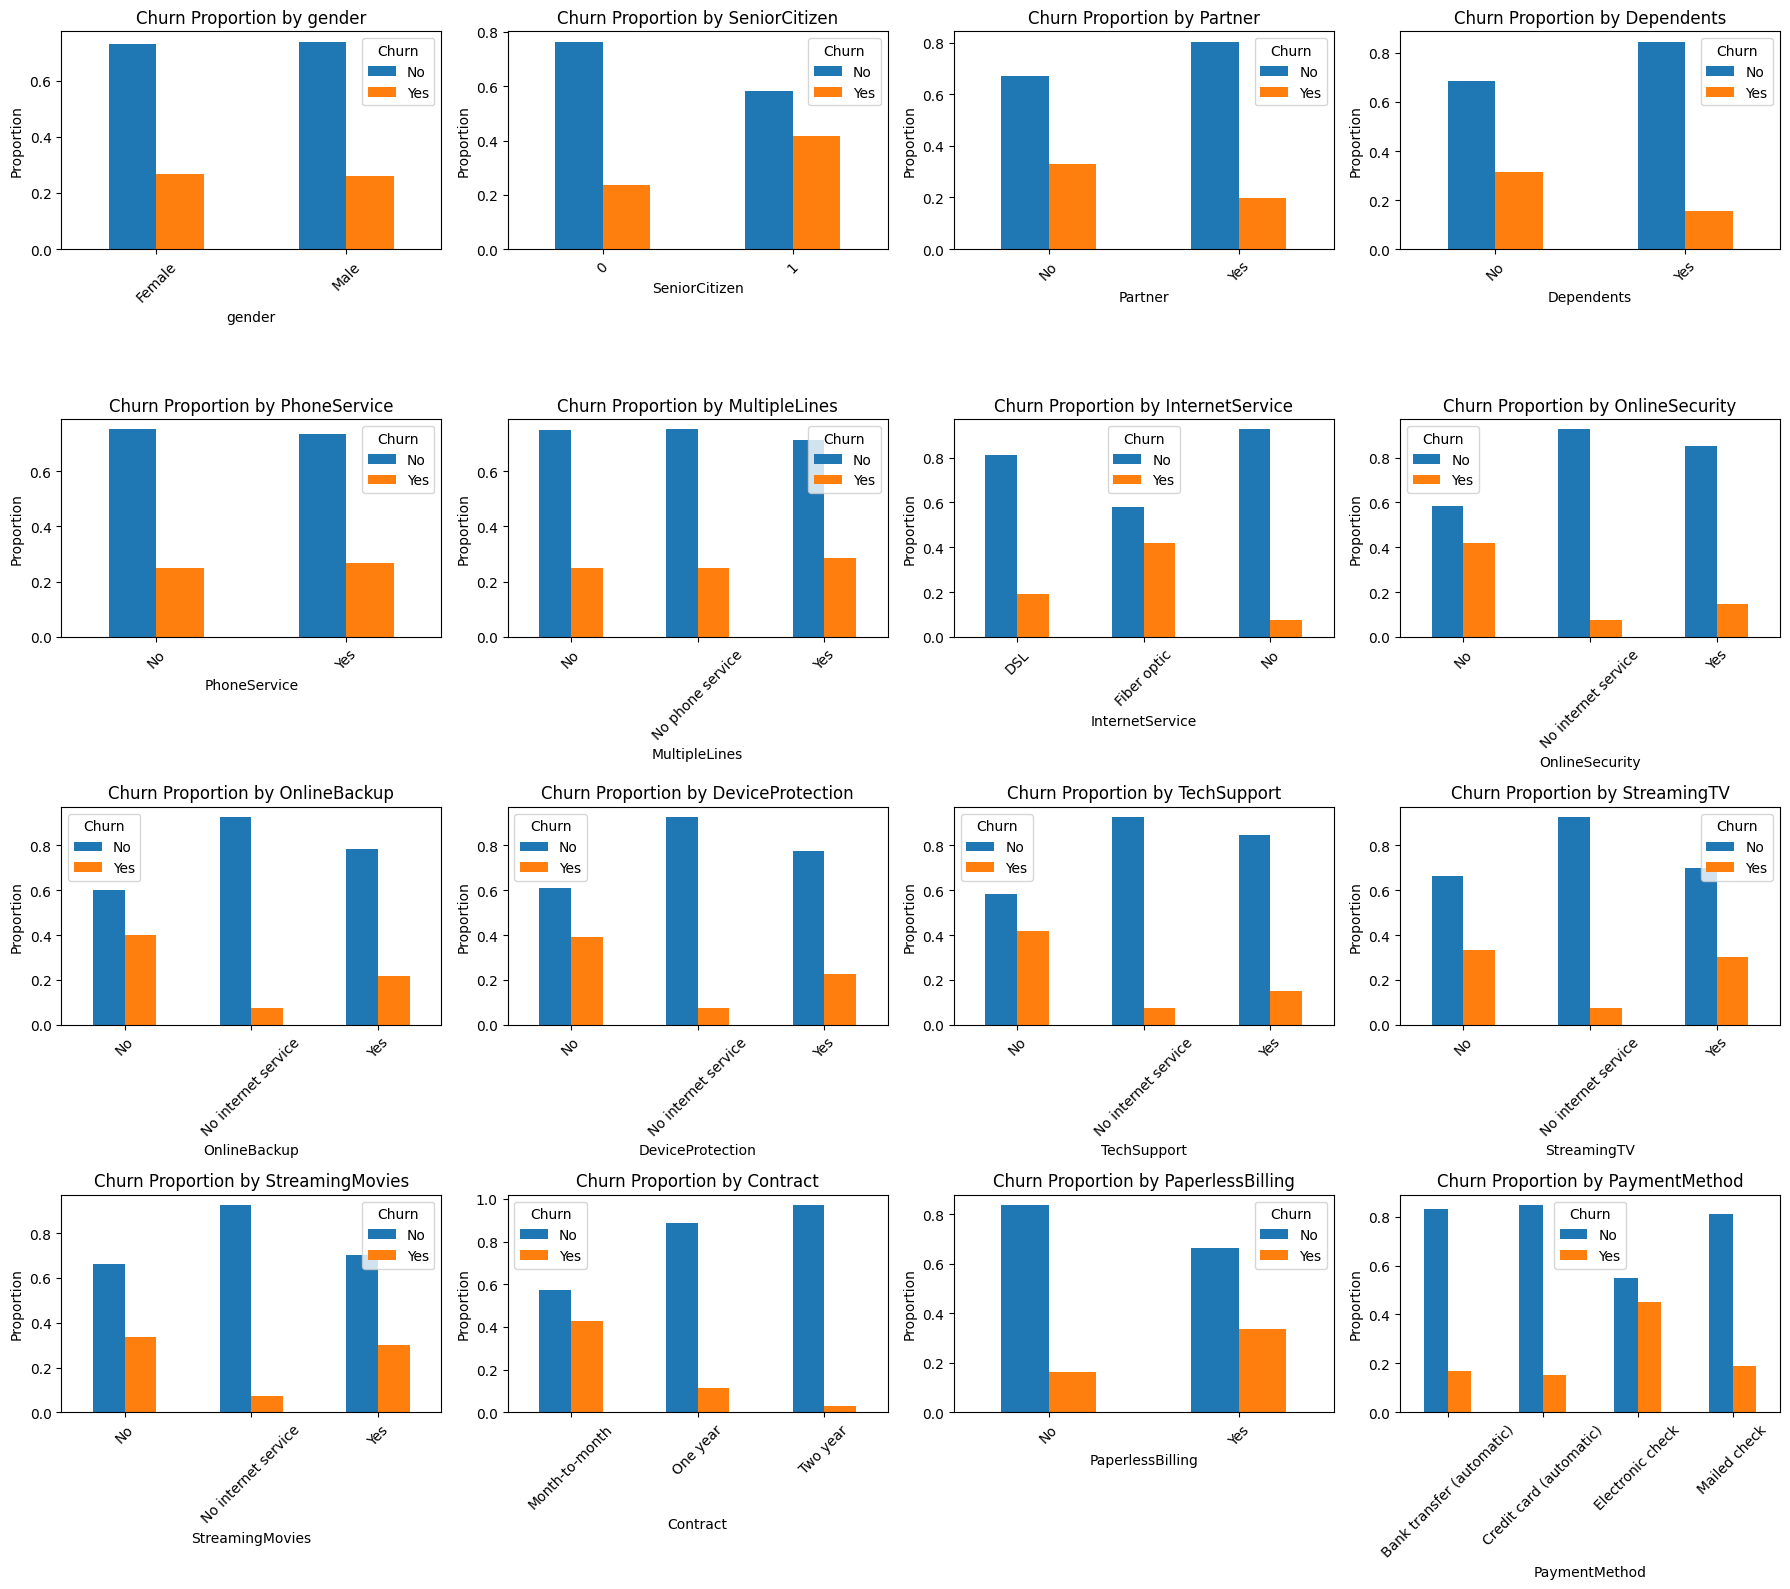

In [14]:
# Visualize the data
# Set up the subplot grid
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18, 16))
axes = axes.flatten()

# Plot each categorical feature in a subplot
for i, column in enumerate(categorical_columns):
    # Calculate normalized proportions because of class imbalance
    normalized_counts = (
        df.groupby(column)['Churn']
        .value_counts(normalize=True)
        .unstack()
    )

    # Plotting the normalized counts as bar plots
    normalized_counts.plot(kind="bar", stacked=False,ax=axes[i])
    # Set title and labels
    axes[i].set_title(f"Churn Proportion by {column}")
    axes[i].set_ylabel('Proportion')
    axes[i].set_xlabel(column)
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x labels for better readability

# Adjust layout
plt.tight_layout()
plt.show()


# Section 5: Feature Engineering

## 5.1 Convert `TotalCharges` column to numeric

In [15]:
# Converting TotalCharges to numeric
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')

## 5.2 Handle the categorical features by converting them to dummies

In [16]:
# One-hot encoding of the categorical features
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(sparse_output=False,drop='first')#without first it will create 2 for each and multicolinear
encoded_arry=encoder.fit_transform(df[categorical_columns])
encoded_df=pd.DataFrame(data=encoded_arry,columns=encoder.get_feature_names_out(categorical_columns))
encoded_df.head()

,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## 5.3 Encode the `Churn` column
- `Yes` as 1
- `No` as 0

In [17]:
# Encode the 'Churn' column
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
df['Churn']=label_encoder.fit_transform(df['Churn'])

In [18]:
df.drop(columns=categorical_columns,inplace=True)
final_df=pd.concat([df,encoded_df],axis=1)

<Axes: >

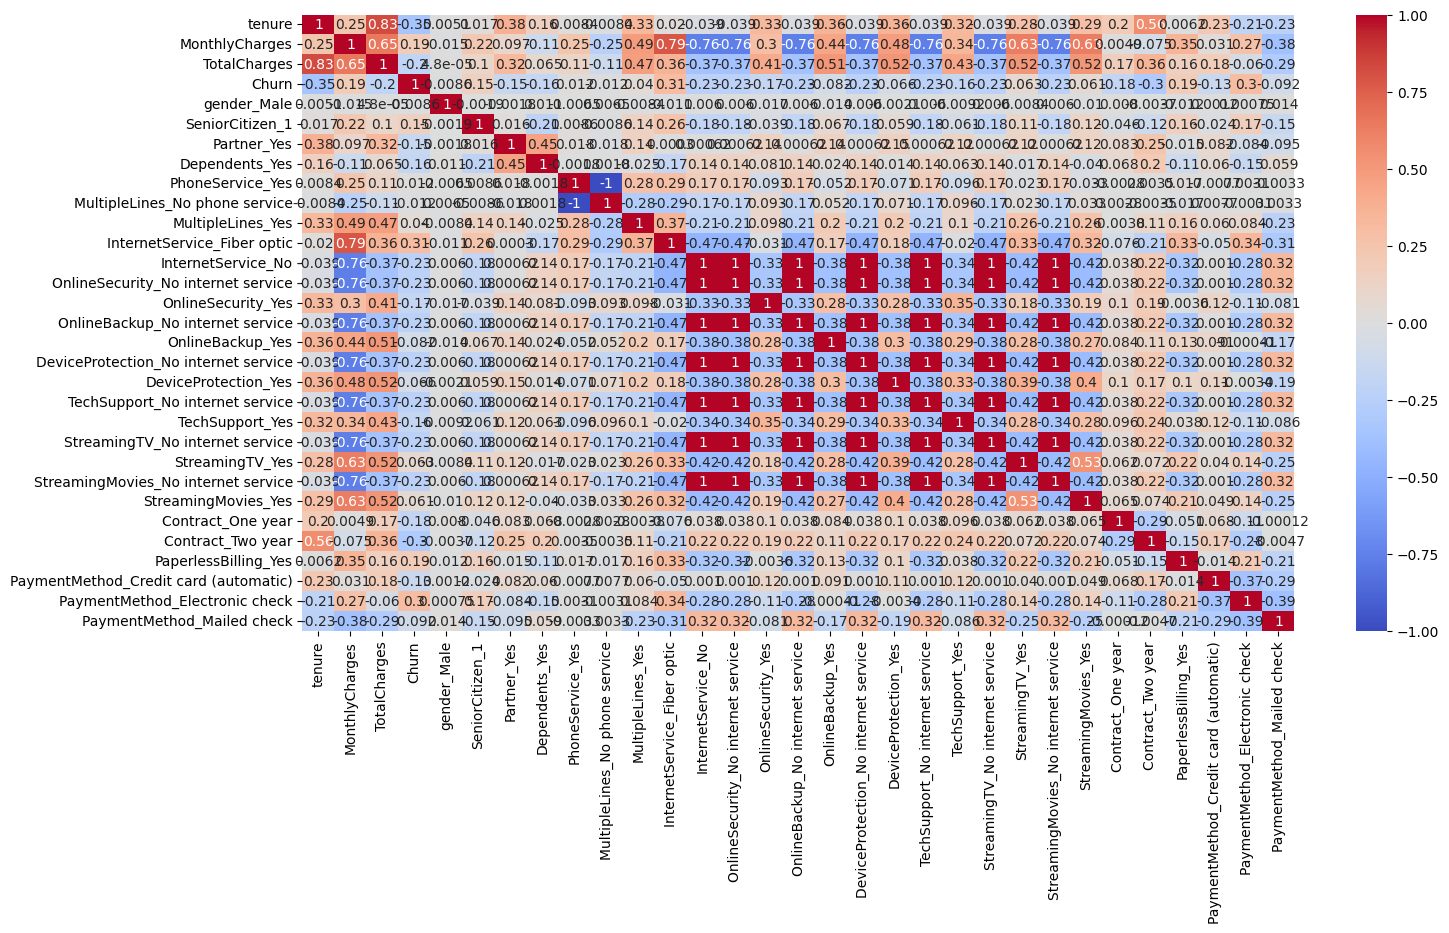

In [19]:
# Create a heatmap displying the correlation coefficients of the variable
plt.figure(figsize=(16,8))
sns.heatmap(data=final_df.corr(),cmap='coolwarm',annot=True)

We clearly see a middle grid with multi colinear featurs with 1's . we need to identify them and remove.


In [20]:
#Use SelectFromModel (If you must drop columns)If you want to explicitly remove the collinear features
#before they hit the model, use scikit-learn's built-in SelectFromModel transformer.
#This fits a temporary Lasso model, identifies the columns with 0 weight (the collinear ones),
#and drops them automatically inside the pipeline.

#Advantage by decouping   final model  can be anything you want not just logistic

#Endd- End Model using initial df_in.


## 5.4 Do a correlation analysis of the dataset

In [21]:
#Top corelated features for Target variable
#filter churn column , drop the row of churn on remaining sort
final_df.corr()['Churn'].drop('Churn').sort_values(ascending=False)

,Churn
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
MonthlyCharges,0.193356
PaperlessBilling_Yes,0.191825
SeniorCitizen_1,0.150889
StreamingTV_Yes,0.063228
StreamingMovies_Yes,0.061382
MultipleLines_Yes,0.040102
PhoneService_Yes,0.011942
gender_Male,-0.008612


In [22]:
#Final Prod ready model

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

# ==========================================
# 1. DATA INGESTION & PRODUCTION FIXES
# ==========================================
# Load raw data

# 1. Define your localized Git structure path
data_path = "data/Telco-Customer-Churn.csv"

# 2. Smart fallback if running on Google Colab
if not os.path.exists(data_path):
    from google.colab import drive
    drive.mount('/content/drive',force_remount=True)
    data_path = "/content/drive/MyDrive/Colab Notebooks/Telco-Customer-Churn.csv"

# 3. Load the data using the resolved path
df_churn = pd.read_csv(data_path)

# Production Fix: Convert TotalCharges spaces to NaN and coerce to numeric
df_churn['TotalCharges']=pd.to_numeric(df_churn['TotalCharges'],errors='coerce')
#we can comment below line as imputer will take care of this based on strategy
#df_churn['TotalCharges']=df_churn['TotalCharges'].fillna(0)

# Convert target variable to binary (0 and 1)
df_churn['Churn']=df_churn['Churn'].map({"Yes" : 1, "No" : 0})
#df_churn['Churn']=df_churn['Churn'].map(lambda x:1 if x=='Yes' else 0)

# ==========================================
# 2. SEPARATE FEATURES, TARGET, AND IDENTIFIERS
# ==========================================
# customerID is dropped from X so the model never sees it
X=df_churn.drop(columns=['customerID','Churn'])
y=df_churn['Churn']

# Split into train and test sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# Keep track of the test customer IDs for the final production reporting
test_customer_ids=df_churn.loc[X_test.index,"customerID"].values



# ==========================================
# 3. DEFINE STATIC FEATURE LISTS (Production Best Practice)
# ==========================================
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

categorical_features = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]
#numeric_features=X_train.select_dtypes(exclude='object').columns.to_list()
#categorical_features=X_train.select_dtypes(include='object').columns.to_list()

# ==========================================
# 4. DEFINE PIPELINE & TRANSFORMERS
# ==========================================
numeric_transformer=Pipeline(steps=[('imputer',SimpleImputer(strategy="median")),
                                    ('scaler',StandardScaler())

                                    ])

categorical_trasformer=Pipeline(steps=[('imputer',SimpleImputer(strategy="most_frequent")),
                                       ('encoder',OneHotEncoder(handle_unknown="ignore",sparse_output=False))

                                      ])

# Combine transformers into a single preprocessor object
preprocessor=ColumnTransformer(transformers=[("num",numeric_transformer,numeric_features),
                                             ("cat",categorical_trasformer,categorical_features)
                                             ],remainder='drop'
                                            )
# ==========================================
# 5. THE PRODUCTION END-TO-END PIPELINE (WITH SMOTE)
# ==========================================
# SMOTE is only applied to training data automatically inside this pipeline
#SMOTE: Instead of duplicating data, SMOTE uses a geometric approach called linear interpolation to generate
#brand-new, realistic examples.For each point in this class, it uses the K-Nearest Neighbors (KNN)
#algorithm to find the most similar data points

prod_lr_churn_pipeline=Pipeline( steps=[
     ('preprocessor', preprocessor), #Impute and encode
    # 2. NEW STEP: Automatically selects optimal features and drops collinear ones
    ('feature_selection', SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', random_state=42))),
     ("smote", SMOTE(random_state=42)),
    # 3. Final Model (Can be Logistic Regression, Random Forest, etc.)
    ('classifier', LogisticRegression(random_state=42))
])

# ==========================================
# 6. TRAIN AND EVALUATE
# ==========================================
# Train the entire end-to-end pipeline
prod_lr_churn_pipeline.fit(X_train, y_train)

# Evaluate on the test set
accuracy = prod_lr_churn_pipeline.score(X_test, y_test)
print(f"Production Pipeline Test Accuracy: {accuracy:.4f}")

# ==========================================
# 7. SAVE THE PIPELINE FOR PRODUCTION DEPLOYMENT
# ==========================================
import joblib

# Save the entire pipeline object (preprocessor + model combined)
joblib.dump(prod_lr_churn_pipeline, 'prod_lr_churn_pipeline.pkl')
print("Pipeline saved successfully as 'prod_lr_churn_pipeline.pkl'")


Mounted at /content/drive
Production Pipeline Test Accuracy: 0.7381
Pipeline saved successfully as 'prod_lr_churn_pipeline.pkl'


In [23]:
import pandas as pd
import joblib

# ==========================================
# 1. LOAD THE TRAINED PRODUCTION PIPELINE
# ==========================================
# This loads everything: preprocessor, feature selection, and the final model
model_path = 'prod_lr_churn_pipeline.pkl'
loaded_pipeline = joblib.load(model_path)
print(f"Successfully loaded production pipeline from: {model_path}")

# ==========================================
# 2. GENERATE PREDICTIONS & PROBABILITIES
# ==========================================
# Predict hard classes (0 or 1)
test_predictions = loaded_pipeline.predict(X_test)

# Predict probabilities [Prob(Not Churn), Prob(Churn)]
test_probabilities = loaded_pipeline.predict_proba(X_test)

# Extract only the probability of churning (the second column)
churn_probabilities = test_probabilities[:, 1]

# ==========================================
# 3. CREATE THE PRODUCTION REPORTING DATAFRAME
# ==========================================
# We map the results back to the specific customer IDs we tracked earlier
production_report = pd.DataFrame({
    'customerID': test_customer_ids,
    'Churn_Probability': churn_probabilities,
    'Predicted_Churn': test_predictions
})

# Sort the report so the customers highest at risk of churning are at the top
production_report = production_report.sort_values(by='Churn_Probability', ascending=False).reset_index(drop=True)

# Map the binary predictions back to human-readable strings for business teams
production_report['Predicted_Churn_Label'] = production_report['Predicted_Churn'].map({1: 'Yes', 0: 'No'})

# Display the top 10 customers most likely to churn
print("\n--- TOP 10 CUSTOMERS AT RISK OF CHURNING ---")
print(production_report[['customerID', 'Churn_Probability', 'Predicted_Churn_Label']].head(10))

# ==========================================
# 3.5 EVALUATE PERFORMANCE METRICS
# ==========================================
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("\n--- MODEL PERFORMANCE EVALUATION ---")

# 1. Classification Report (Precision, Recall, F1-Score)
# This breaks down metrics for both classes (0 and 1)
print("\n[Classification Report]")
print(classification_report(y_test, test_predictions, target_names=['No Churn', 'Churn']))

# 2. ROC-AUC Score
# Uses continuous probabilities to measure how well the model ranks churn risk
roc_auc = roc_auc_score(y_test, churn_probabilities)
print(f"[ROC-AUC Score]: {roc_auc:.4f}")

# 3. Confusion Matrix Dataframe
# Format the raw array into a clean, human-readable layout
cm = confusion_matrix(y_test, test_predictions)
cm_df = pd.DataFrame(
    cm,
    index=['Actual: No Churn', 'Actual: Churn'],
    columns=['Predicted: No Churn', 'Predicted: Churn']
)
print("\n[Confusion Matrix Table]")
print(cm_df)

# ==========================================
# 4. EXPORT FOR BUSINESS USE
# ==========================================
# Save the results to a CSV file for your marketing or retention teams
output_csv_path = 'churn_predictions_output.csv'
production_report.to_csv(output_csv_path, index=False)
print(f"\nProduction report successfully saved to: {output_csv_path}")

Successfully loaded production pipeline from: prod_lr_churn_pipeline.pkl

--- TOP 10 CUSTOMERS AT RISK OF CHURNING ---
   customerID  Churn_Probability Predicted_Churn_Label
0  5178-LMXOP           0.939379                   Yes
1  0295-PPHDO           0.934731                   Yes
2  9057-SIHCH           0.930448                   Yes
3  1069-XAIEM           0.927029                   Yes
4  8161-QYMTT           0.926234                   Yes
5  2545-EBUPK           0.925532                   Yes
6  6023-YEBUP           0.923484                   Yes
7  8884-ADFVN           0.922186                   Yes
8  4750-ZRXIU           0.921879                   Yes
9  6861-XWTWQ           0.921454                   Yes

--- MODEL PERFORMANCE EVALUATION ---

[Classification Report]
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.79      0.62       374

    accuracy                           0.74      